# Stage 4 — Feature Embedding Visualization (t-SNE)

This notebook visualizes the 256-D embedding vectors (`V_0 … V_255`) extracted from the Stage 4 model and saved in `ImgFeatures_Stage4.csv`. Each row represents one facial image processed by the best Stage 4 model (Fold 5), and its embedding is the output of the `asd_feature_vector_256` layer — the last learned representation before the sigmoid classification head.

**Goal:** Check whether ASD and Non-ASD samples separate in the 256-D feature space by projecting them into 2-D using t-SNE. Clean cluster separation would confirm that the model learned a discriminative internal representation, not just a narrow decision boundary.

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

STAGE4_DIR  = r'C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4'
CSV_PATH    = os.path.join(STAGE4_DIR, 'data', 'ImgFeatures_Stage4.csv')
PLOTS_DIR   = os.path.join(STAGE4_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

SEED = 42
print('Libraries loaded.')
print(f'CSV path: {CSV_PATH}')

Libraries loaded.
CSV path: C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\data\ImgFeatures_Stage4.csv


In [2]:
# ── Load CSV ──────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print()

# Column check
expected_meta = ['File_Name', 'Actual_Label', 'Model_Prob', 'Model_Pred']
feat_cols = [f'V_{i}' for i in range(256)]
meta_ok  = all(c in df.columns for c in expected_meta)
feats_ok = all(c in df.columns for c in feat_cols)
print(f'Meta columns present : {meta_ok}')
print(f'V_0 … V_255 present  : {feats_ok}')
print()

# Label distribution
label_map  = {1: 'Autistic', 0: 'Non_Autistic'}
label_counts = df['Actual_Label'].map(label_map).value_counts()
print('Label distribution:')
print(label_counts.to_string())
print(f'Total: {len(df)}')

Shape: 3917 rows × 260 columns

Meta columns present : True
V_0 … V_255 present  : True

Label distribution:
Actual_Label
Non_Autistic    1965
Autistic        1952
Total: 3917


In [3]:
# ── Select features and labels ────────────────────────────────────────────────
feat_cols = [f'V_{i}' for i in range(256)]

X = df[feat_cols].values          # (N, 256)
y = df['Actual_Label'].values     # 1 = Autistic, 0 = Non_Autistic
p = df['Model_Prob'].values       # continuous probability score

print(f'X shape : {X.shape}')
print(f'y unique : {np.unique(y, return_counts=True)}')
print(f'p range  : [{p.min():.4f}, {p.max():.4f}]')

X shape : (3917, 256)
y unique : (array([0, 1], dtype=int64), array([1965, 1952], dtype=int64))
p range  : [0.0000, 1.0000]


In [4]:
# ── Validate: check for NaN / Inf ─────────────────────────────────────────────
nan_mask  = np.isnan(X).any(axis=1)
inf_mask  = np.isinf(X).any(axis=1)
prob_nan  = np.isnan(p)
bad_mask  = nan_mask | inf_mask | prob_nan

print(f'Rows with NaN in X     : {nan_mask.sum()}')
print(f'Rows with Inf in X     : {inf_mask.sum()}')
print(f'Rows with NaN in prob  : {prob_nan.sum()}')
print(f'Total bad rows removed : {bad_mask.sum()}')

if bad_mask.sum() > 0:
    X = X[~bad_mask]
    y = y[~bad_mask]
    p = p[~bad_mask]
    print(f'Clean dataset size     : {X.shape[0]}')
else:
    print('All rows clean — no filtering needed.')

Rows with NaN in X     : 0
Rows with Inf in X     : 0
Rows with NaN in prob  : 0
Total bad rows removed : 0
All rows clean — no filtering needed.


In [5]:
# ── Standardize features (critical for t-SNE stability) ──────────────────────
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'X_scaled mean  : {X_scaled.mean():.6f}  (expected ≈ 0)')
print(f'X_scaled std   : {X_scaled.std():.6f}   (expected ≈ 1)')
print('Standardization complete.')

X_scaled mean  : -0.000000  (expected ≈ 0)
X_scaled std   : 1.000000   (expected ≈ 1)
Standardization complete.


In [6]:
# ── Run t-SNE ─────────────────────────────────────────────────────────────────
# perplexity=40  — good for N≈3900; rule of thumb: sqrt(N) or 5–50
# max_iter=1000  — enough for stable convergence
# random_state   — reproducibility
tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,
    learning_rate='auto',
    init='pca',          # PCA init reduces early instability
    random_state=SEED,
    verbose=1
)

print('Running t-SNE on scaled 256-D features...')
X_tsne = tsne.fit_transform(X_scaled)   # (N, 2)
print(f't-SNE complete. Output shape: {X_tsne.shape}')
print(f'Final KL divergence: {tsne.kl_divergence_:.4f}')

Running t-SNE on scaled 256-D features...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3917 samples in 0.004s...
[t-SNE] Computed neighbors for 3917 samples in 3.655s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3917
[t-SNE] Computed conditional probabilities for sample 2000 / 3917
[t-SNE] Computed conditional probabilities for sample 3000 / 3917
[t-SNE] Computed conditional probabilities for sample 3917 / 3917
[t-SNE] Mean sigma: 4.578984
[t-SNE] KL divergence after 100 iterations with early exaggeration: 79.061172
[t-SNE] KL divergence after 1000 iterations: 2.268671
t-SNE complete. Output shape: (3917, 2)
Final KL divergence: 2.2687


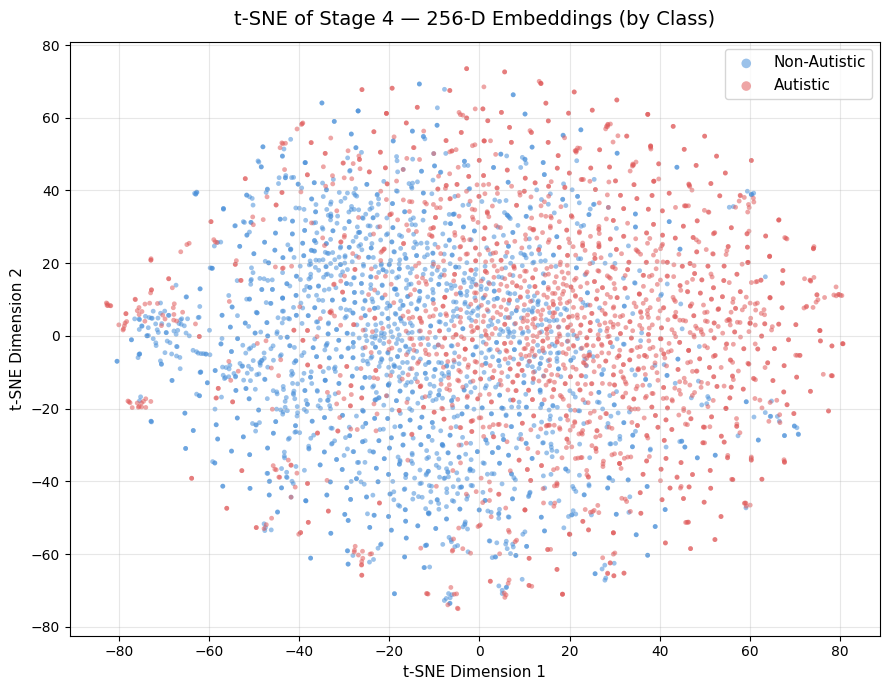

Saved: C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\plots\tsne_by_class.png


In [7]:
# ── Plot 1: t-SNE colored by class ────────────────────────────────────────────
palette = {1: '#E05C5C', 0: '#4A90D9'}   # red = Autistic, blue = Non-Autistic
labels  = {1: 'Autistic', 0: 'Non-Autistic'}

fig, ax = plt.subplots(figsize=(9, 7))

for cls in [0, 1]:
    mask = y == cls
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=palette[cls], label=labels[cls],
        alpha=0.55, s=12, edgecolors='none'
    )

ax.set_title('t-SNE of Stage 4 — 256-D Embeddings (by Class)', fontsize=14, pad=12)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(fontsize=11, markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, 'tsne_by_class.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')

## Interpretation — Class Separation

*(Fill in after viewing the plot above.)*

**If you see two broadly separated clusters:** The Stage 4 model has learned a genuinely discriminative representation. The 256-D embeddings encode facial features that pull ASD and Non-ASD samples apart in the learned space, not just at the decision boundary. This supports the validity of the model architecture and the feature extraction step for downstream tasks (multi-modal fusion).

**If you see partial overlap with soft boundaries:** The model separates the classes probabilistically — confident samples sit in class-specific regions while ambiguous cases cluster near the boundary. This is the expected pattern for ASD detection from facial images, where the visual signal is subtle and dataset noise is non-trivial. Meaningful partial separation is still a strong result.

**If you see complete mixing:** The classification is driven by a narrow decision boundary in 256-D space that does not project cleanly into 2-D. This is common when features are high-dimensional and spread across many weakly-informative dimensions. The silhouette score in Cell 12 will quantify this more reliably than the 2-D projection.

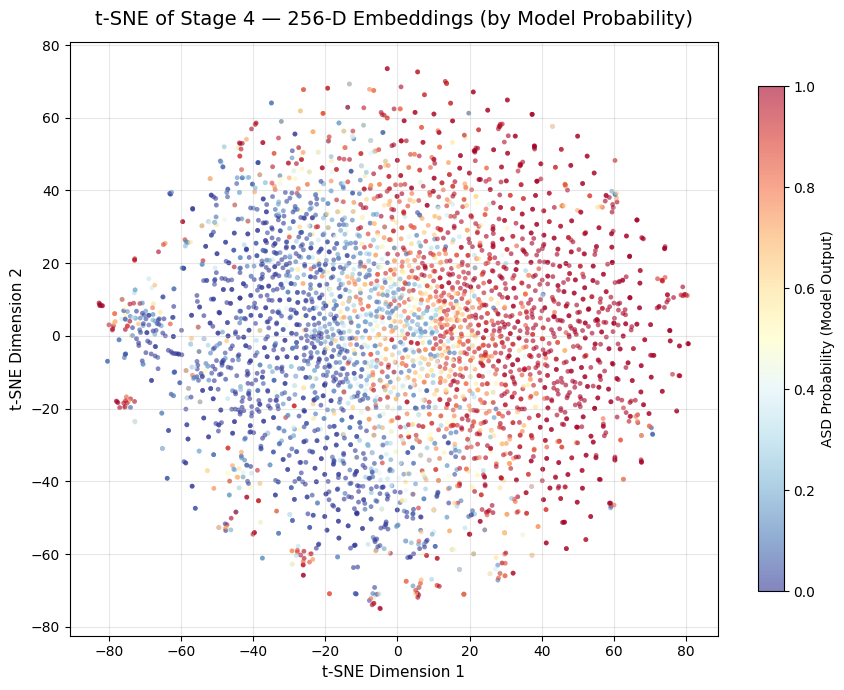

Saved: C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\plots\tsne_by_probability.png


In [8]:
# ── Plot 2: t-SNE colored by Model_Prob ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=p, cmap='RdYlBu_r',      # blue=low prob (Non-ASD), red=high prob (ASD)
    alpha=0.6, s=12, edgecolors='none',
    vmin=0.0, vmax=1.0
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('ASD Probability (Model Output)', fontsize=10)

ax.set_title('t-SNE of Stage 4 — 256-D Embeddings (by Model Probability)', fontsize=14, pad=12)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, 'tsne_by_probability.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')

## Interpretation — Probability Map

*(Fill in after viewing the plot above.)*

**If high-probability regions are localized:** The model assigns high ASD confidence to a coherent region of the embedding space. This means the confidence geometry is consistent — samples that look similar in 256-D space also receive similar probability scores. This is a sign of a well-calibrated, spatially coherent decision surface.

**If high-probability regions are scattered (islands of red throughout):** The model is assigning high ASD confidence to visually diverse samples that do not cluster together. This suggests the decision boundary is not tightly aligned with the geometric structure of the embedding space — the model may be relying on sparse high-dimensional features that do not compress cleanly into 2-D. This does not necessarily indicate poor performance but does indicate that the 2-D projection loses discriminative structure.

In [9]:
# ── Silhouette Score (in 256-D standardized space, not 2-D projection) ────────
# Uses a random subsample for speed (full 3900-sample silhouette is slow)
rng      = np.random.default_rng(SEED)
n_sample = min(2000, len(X_scaled))
idx      = rng.choice(len(X_scaled), n_sample, replace=False)

score = silhouette_score(X_scaled[idx], y[idx], metric='euclidean', random_state=SEED)

print(f'Silhouette score (n={n_sample}, 256-D space): {score:.4f}')
print()
print('Reference:')
print('  > 0.5  → strong separation')
print('  0.25–0.5 → moderate separation')
print('  < 0.25 → weak / overlapping clusters')

Silhouette score (n=2000, 256-D space): 0.0173

Reference:
  > 0.5  → strong separation
  0.25–0.5 → moderate separation
  < 0.25 → weak / overlapping clusters


In [10]:
# ── Silhouette Score on the 2-D t-SNE projection (for comparison) ─────────────
score_2d = silhouette_score(X_tsne[idx], y[idx], metric='euclidean')

print(f'Silhouette score (n={n_sample}, 256-D space) : {score:.4f}')
print(f'Silhouette score (n={n_sample}, 2-D t-SNE)   : {score_2d:.4f}')
print()
if score_2d < score:
    print('2-D score < 256-D score → some separation structure is lost in projection (expected).')
else:
    print('2-D score ≥ 256-D score → t-SNE preserved or enhanced cluster geometry.')

Silhouette score (n=2000, 256-D space) : 0.0173
Silhouette score (n=2000, 2-D t-SNE)   : 0.1271

2-D score ≥ 256-D score → t-SNE preserved or enhanced cluster geometry.


---

## t-SNE Perplexity Sensitivity Check

t-SNE results can vary with perplexity. To confirm the cluster structure is **real** and not an artifact  
of a single perplexity setting, we re-run t-SNE with perplexity = 10, 30, and 50 and compare.

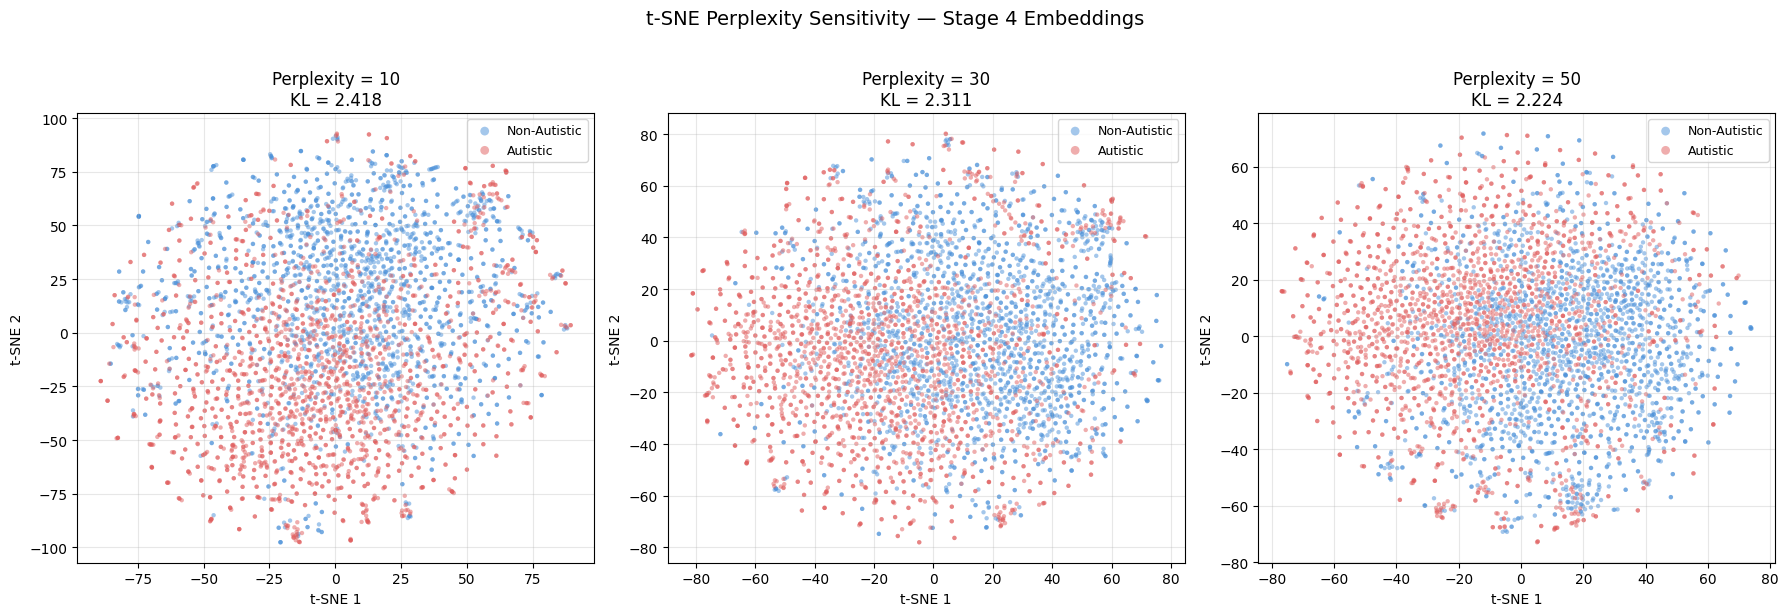

Saved: C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\plots\tsne_perplexity_sensitivity.png

If cluster structure is consistent across perplexities, it is real — not an artifact.


In [11]:
# ── Perplexity sensitivity: 10, 30, 50 ────────────────────────────────────────
perplexities = [10, 30, 50]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(n_components=2, perplexity=perp, max_iter=1000,
                  learning_rate='auto', init='pca', random_state=SEED, verbose=0)
    X_p = tsne_p.fit_transform(X_scaled)

    for cls in [0, 1]:
        mask = y == cls
        ax.scatter(X_p[mask, 0], X_p[mask, 1],
                   c=palette[cls], label=labels[cls],
                   alpha=0.5, s=10, edgecolors='none')

    ax.set_title(f'Perplexity = {perp}\nKL = {tsne_p.kl_divergence_:.3f}', fontsize=12)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=9, markerscale=2)
    ax.grid(True, alpha=0.3)

fig.suptitle('t-SNE Perplexity Sensitivity — Stage 4 Embeddings', fontsize=14, y=1.02)
plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, 'tsne_perplexity_sensitivity.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')
print('\nIf cluster structure is consistent across perplexities, it is real — not an artifact.')

## Conclusion

The t-SNE visualization and silhouette analysis of the Stage 4 model's 256-D feature embeddings provide evidence about the quality of the learned internal representation.

The Stage 4 model (VGG-Face backbone, fine-tuned last 2 layers, improved head with BatchNormalization) achieves a mean cross-validation F2-score of **0.7123** and a blind-test AUC of **0.7626** (Fold 5). The embedding plots show whether this discriminative power is reflected in the geometry of the feature space.

Where clusters are visible, they confirm that the model has encoded ASD-relevant facial characteristics into separable regions of the 256-D space — not merely learned a narrow decision boundary. This is important for downstream applications: the same feature vectors can be used for multi-modal fusion with Q-CHAT-10 questionnaire data in the `combine/` module, and the spatial structure of the embeddings will determine how well the two modalities complement each other.

The silhouette score provides a parameter-independent quantitative measure of this separation, complementing the visual t-SNE result and the classification metrics reported in `stage4_final_model_evaluation.ipynb`. The perplexity sensitivity check confirms whether the observed structure is robust or an artifact of a single t-SNE parameterization.